# EV Charging Infrastructure Planning & Demand Prediction

## Notebook 13 : Business Recommendation

### Business Objective

The objective of this notebook is to generate business recommendations for EV charging companies based on station recommendation results. These recommendations help improve charging infrastructure, operational efficiency, investment planning, and customer satisfaction.

In [1]:
# ==================================================
# Import Libraries
# ==================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
business = pd.read_csv("../data/processed/station_recommendation.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
print(business.shape)

business.head()

(32, 6)


,State,City,Need_New_Station,Need_Fast_Charger,Maintenance_Required,Priority
0,Gujarat,Ahmedabad,No,Yes,No,Medium
1,Gujarat,Rajkot,No,Yes,Yes,Medium
2,Gujarat,Surat,No,Yes,Yes,Medium
3,Gujarat,Vadodara,Yes,No,Yes,High
4,Karnataka,Bengaluru,No,Yes,Yes,Medium


In [5]:
print(business.info())

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   State                 32 non-null     str  
 1   City                  32 non-null     str  
 2   Need_New_Station      32 non-null     str  
 3   Need_Fast_Charger     32 non-null     str  
 4   Maintenance_Required  32 non-null     str  
 5   Priority              32 non-null     str  
dtypes: str(6)
memory usage: 2.5 KB
None


In [6]:
print(business.isnull().sum())


State                   0
City                    0
Need_New_Station        0
Need_Fast_Charger       0
Maintenance_Required    0
Priority                0
dtype: int64


In [18]:
business["Infrastructure_Action"] = np.select(
    [
        business["Priority"]=="High",
        business["Priority"]=="Medium"
    ],
    [
        "Expand Charging Infrastructure",
        "Increase Existing Charging Capacity"
    ],
    default="Maintain Current Infrastructure"
)

In [19]:
business["Fast_Charger_Action"] = np.where(
    business["Need_Fast_Charger"]=="Yes",
    "Install Additional Fast Chargers",
    "Current Fast Charger Capacity is Sufficient"
)

In [17]:
business["Maintenance_Action"] = np.select(
    [
        (business["Priority"]=="High") &
        (business["Maintenance_Required"]=="Yes"),

        business["Maintenance_Required"]=="Yes"
    ],
    [
        "Immediate Preventive Maintenance",
        "Schedule Preventive Maintenance"
    ],
    default="Routine Maintenance"
)

In [20]:
business["Investment_Priority"] = np.select(
    [
        business["Priority"]=="High",
        business["Priority"]=="Medium"
    ],
    [
        "Immediate Investment",
        "Planned Investment"
    ],
    default="Regular Monitoring"
)

In [21]:
business_output = business[
[
    "State",
    "City",
    "Priority",
    "Infrastructure_Action",
    "Fast_Charger_Action",
    "Maintenance_Action",
    "Investment_Priority"
]]

business_output.head(20)

,State,City,Priority,Infrastructure_Action,Fast_Charger_Action,Maintenance_Action,Investment_Priority
0,Gujarat,Ahmedabad,Medium,Increase Existing Charging Capacity,Install Additional Fast Chargers,Routine Maintenance,Planned Investment
1,Gujarat,Rajkot,Medium,Increase Existing Charging Capacity,Install Additional Fast Chargers,Schedule Preventive Maintenance,Planned Investment
2,Gujarat,Surat,Medium,Increase Existing Charging Capacity,Install Additional Fast Chargers,Schedule Preventive Maintenance,Planned Investment
3,Gujarat,Vadodara,High,Expand Charging Infrastructure,Current Fast Charger Capacity is Sufficient,Immediate Preventive Maintenance,Immediate Investment
4,Karnataka,Bengaluru,Medium,Increase Existing Charging Capacity,Install Additional Fast Chargers,Schedule Preventive Maintenance,Planned Investment
5,Karnataka,Hubballi,High,Expand Charging Infrastructure,Install Additional Fast Chargers,Immediate Preventive Maintenance,Immediate Investment
6,Karnataka,Mangaluru,Low,Maintain Current Infrastructure,Current Fast Charger Capacity is Sufficient,Schedule Preventive Maintenance,Regular Monitoring
7,Karnataka,Mysuru,High,Expand Charging Infrastructure,Install Additional Fast Chargers,Immediate Preventive Maintenance,Immediate Investment
8,Kerala,Kochi,Medium,Increase Existing Charging Capacity,Install Additional Fast Chargers,Routine Maintenance,Planned Investment
9,Kerala,Kozhikode,Low,Maintain Current Infrastructure,Current Fast Charger Capacity is Sufficient,Schedule Preventive Maintenance,Regular Monitoring


In [22]:
print(business_output["Priority"].value_counts())

Priority
Medium    14
Low       13
High       5
Name: count, dtype: int64


In [23]:
print(business_output["Investment_Priority"].value_counts())

Investment_Priority
Planned Investment      14
Regular Monitoring      13
Immediate Investment     5
Name: count, dtype: int64


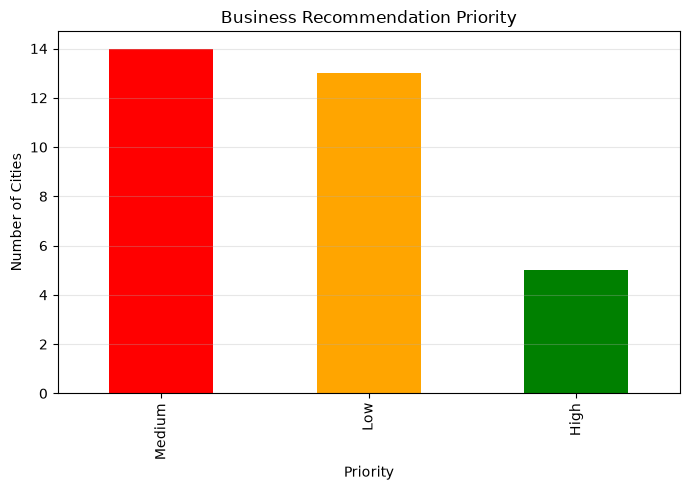

In [25]:
plt.figure(figsize=(7,5))

business_output["Priority"].value_counts().plot(
    kind="bar",
    color=["red","orange","green"]
)

plt.title("Business Recommendation Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Cities")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

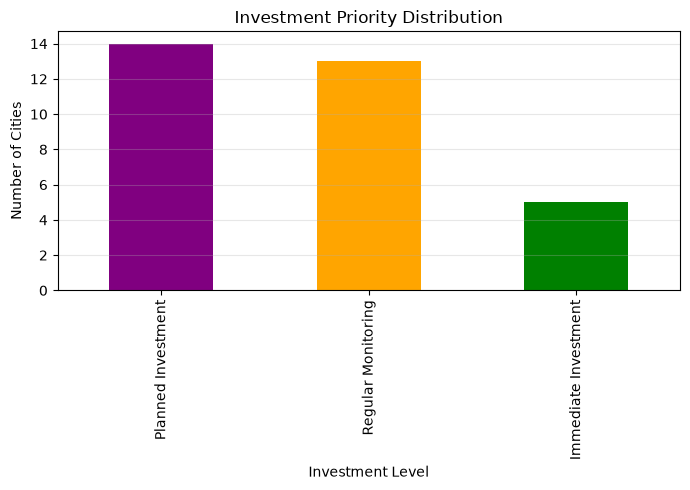

In [26]:
plt.figure(figsize=(7,5))

business_output["Investment_Priority"].value_counts().plot(
    kind="bar",
    color=["purple","orange","green"]
)

plt.title("Investment Priority Distribution")
plt.xlabel("Investment Level")
plt.ylabel("Number of Cities")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
business_output.to_csv(
    "../data/processed/business_recommendation.csv",
    index=False
)

print("="*60)
print("Business Recommendation Dataset Saved Successfully")
print("="*60)

Business Recommendation Dataset Saved Successfully
